In [1]:
import pandas as pd
print("Đã import thành công pandas!")

Đã import thành công pandas!


In [2]:
df5 = pd.read_csv('BT5.Nonlinear_data.csv')

print("=== 5 DÒNG ĐẦU TIÊN ===")
display(df5.head())

print("\n=== THÔNG TIN BỘ DỮ LIỆU ===")
df5.info()


=== 5 DÒNG ĐẦU TIÊN ===


,x,y
0,0.00000,4.427319
1,0.10101,23.835430
2,0.20202,20.719661
3,0.30303,11.851864
4,0.40404,-14.772347



=== THÔNG TIN BỘ DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       100 non-null    float64
 1   y       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

print("Đã import numpy, LinearRegression, curve_fit và matplotlib!")

Đã import numpy, LinearRegression, curve_fit và matplotlib!


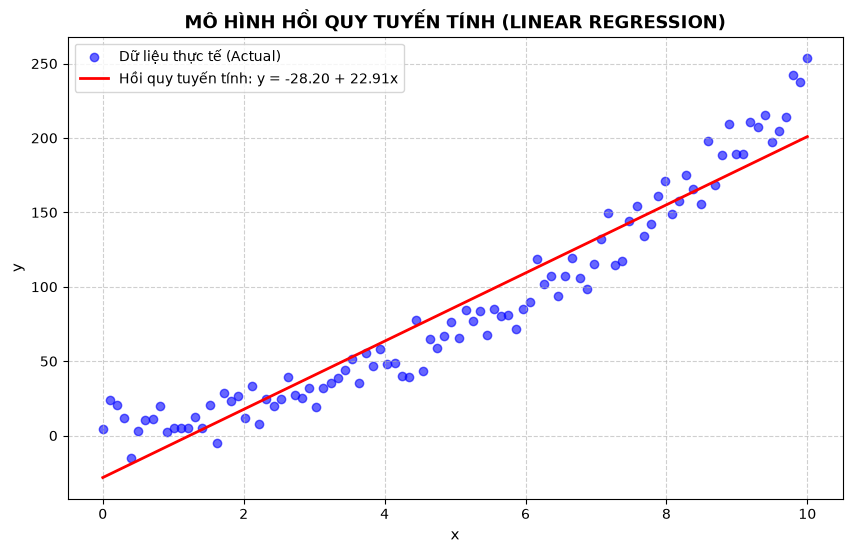

In [4]:
X5 = df5[['x']]
x_arr = df5['x'].values
y5 = df5['y'].values

model_linear = LinearRegression()
model_linear.fit(X5, y5)
y_pred_linear = model_linear.predict(X5)

plt.figure(figsize=(10, 6))
plt.scatter(x_arr, y5, color='blue', alpha=0.6, label='Dữ liệu thực tế (Actual)')
plt.plot(x_arr, y_pred_linear, color='red', linewidth=2, 
         label=f'Hồi quy tuyến tính: y = {model_linear.intercept_:.2f} + {model_linear.coef_[0]:.2f}x')
plt.title('MÔ HÌNH HỒI QUY TUYẾN TÍNH (LINEAR REGRESSION)', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

=== HỆ SỐ CỦA HÀM PHI TUYẾN ===
a = 2.1912, b = 1.0001, c = 7.9493
Hàm phi tuyến tìm được: y = 2.1912*x^2 + 1.0001*x + 7.9493


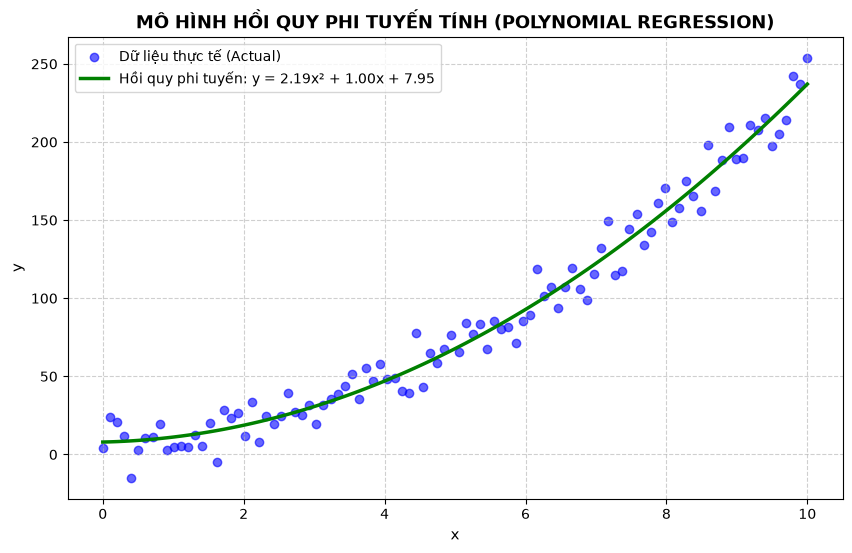

In [5]:
def poly2(x, a, b, c):
    return a * (x**2) + b * x + c

popt, pcov = curve_fit(poly2, x_arr, y5)
a, b, c = popt

y_pred_poly = poly2(x_arr, a, b, c)

print("=== HỆ SỐ CỦA HÀM PHI TUYẾN ===")
print(f"a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")
print(f"Hàm phi tuyến tìm được: y = {a:.4f}*x^2 + {b:.4f}*x + {c:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(x_arr, y5, color='blue', alpha=0.6, label='Dữ liệu thực tế (Actual)')
plt.plot(x_arr, y_pred_poly, color='green', linewidth=2.5, 
         label=f'Hồi quy phi tuyến: y = {a:.2f}x² + {b:.2f}x + {c:.2f}')
plt.title('MÔ HÌNH HỒI QUY PHI TUYẾN TÍNH (POLYNOMIAL REGRESSION)', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

CHỈ SỐ ĐÁNH GIÁ           | MÔ HÌNH TUYẾN TÍNH | MÔ HÌNH PHI TUYẾN
Mean Squared Error (MSE)  | 389.4324           | 111.8985
Root Mean Squared (RMSE)  | 19.7340            | 10.5782


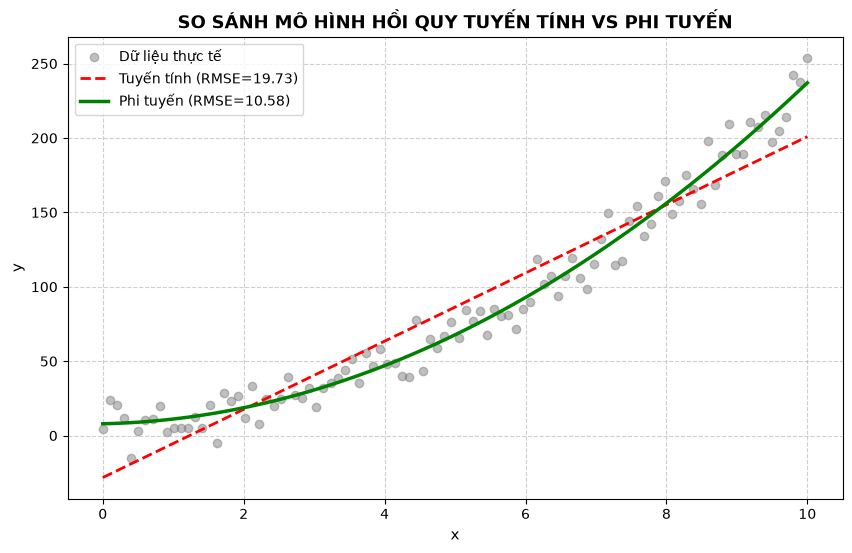


=== SO SÁNH VÀ KẾT LUẬN ===
1. Về sai số: RMSE của mô hình phi tuyến (10.58) giảm gần 50% so với mô hình tuyến tính (19.73).
2. Về hình dạng: Dữ liệu thực tế có xu hướng đường cong parabol. Mô hình phi tuyến bậc 2 ôm sát quỹ đạo dữ liệu, trong khi đường thẳng tuyến tính bị lệch lớn ở các vùng cực trị.
=> KẾT LUẬN: Mô hình hồi quy phi tuyến tính phù hợp vượt trội và chính xác hơn hẳn.


In [6]:
mse_linear = mean_squared_error(y5, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

mse_poly = mean_squared_error(y5, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print("=" * 60)
print(f"{'CHỈ SỐ ĐÁNH GIÁ':<25} | {'MÔ HÌNH TUYẾN TÍNH':<18} | {'MÔ HÌNH PHI TUYẾN'}")
print("=" * 60)
print(f"{'Mean Squared Error (MSE)':<25} | {mse_linear:<18.4f} | {mse_poly:.4f}")
print(f"{'Root Mean Squared (RMSE)':<25} | {rmse_linear:<18.4f} | {rmse_poly:.4f}")
print("=" * 60)

plt.figure(figsize=(10, 6))
plt.scatter(x_arr, y5, color='gray', alpha=0.5, label='Dữ liệu thực tế')
plt.plot(x_arr, y_pred_linear, color='red', linestyle='--', linewidth=2, label=f'Tuyến tính (RMSE={rmse_linear:.2f})')
plt.plot(x_arr, y_pred_poly, color='green', linewidth=2.5, label=f'Phi tuyến (RMSE={rmse_poly:.2f})')
plt.title('SO SÁNH MÔ HÌNH HỒI QUY TUYẾN TÍNH VS PHI TUYẾN', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("\n=== SO SÁNH VÀ KẾT LUẬN ===")
print(f"1. Về sai số: RMSE của mô hình phi tuyến ({rmse_poly:.2f}) giảm gần 50% so với mô hình tuyến tính ({rmse_linear:.2f}).")
print("2. Về hình dạng: Dữ liệu thực tế có xu hướng đường cong parabol. Mô hình phi tuyến bậc 2 ôm sát quỹ đạo dữ liệu, trong khi đường thẳng tuyến tính bị lệch lớn ở các vùng cực trị.")
print("=> KẾT LUẬN: Mô hình hồi quy phi tuyến tính phù hợp vượt trội và chính xác hơn hẳn.")
